In [13]:
import numpy as np
import matplotlib.pyplot as plt
from games.blotto import Blotto
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

# Blotto

Juego de **suma cero** con 2 agentes, donde cada jugador distribuye **S soldados** entre **N campos de batalla**. Gana cada campo quien envíe más soldados; gana el juego quien gane más campos.

Configuración: `S = 6` soldados, `N = 3` campos de batalla.

Las estrategias (puras) son todas las distribuciones ordenadas no decrecientes:

| Índice | Distribución | Interpretación |
|--------|-------------|----------------|
| m₀ | (1, 1, 4) | foco en un campo de batalla|
| m₁ | (1, 2, 3) | Distribución escalonada |
| m₂ | (2, 2, 2) | Distribución uniforme |

La función de utilidad: `u₀ = +1` si agent_0 gana más campos, `-1` si pierde, `0` en empate.

In [14]:
g = Blotto(S=6, N=3)

In [15]:
g.reset()

In [16]:
g.agents

['agent_0', 'agent_1']

In [17]:
g._moves


[[1, 1, 4], [1, 2, 3], [2, 2, 2]]

In [18]:
# Variables globales usadas en todo el notebook
move_labels = [str(tuple(m)) for m in g._moves]
R = g._R
move_labels

['(1, 1, 4)', '(1, 2, 3)', '(2, 2, 2)']

## Análisis

### Estrategias dominantes

| Relación | Tipo |
|----------|------|
| m₂ = (2,2,2) **débilmente domina** a m₀ = (1,1,4) | m₂ ≥ m₀ en todos los escenarios; estrictamente mejor cuando el oponente juega m₀ |
| m₂ = (2,2,2) **débilmente domina** a m₁ = (1,2,3) | m₂ ≥ m₁ en todos los escenarios; estrictamente mejor cuando el oponente juega m₀ |

**Sobre m₀ y m₁:** formalmente m₁ también débilmente domina a m₀, pero la relación es trivial en la práctica: m₀ y m₁ **empatan en todos los escenarios donde el oponente no juega m₂**. Sin m₂ en el soporte del oponente, son estratégicamente equivalentes.

**Conclusión de dominancia:**
- m₂ = (2,2,2) es la única estrategia **débilmente dominante**.
- m₀ = (1,1,4) es la única estrategia **débilmente dominada** (por m₂).
- m₁ = (1,2,3) junto con m₂ forman el soporte de los equilibrios de Nash.
- **No existe estrategia estrictamente dominante.**

### Equilibrios de Nash

Eliminando m₀ por débilmente dominada, m₁ y m₂ dan **siempre utilidad 0** entre sí. Cualquier combinación de m₁ y m₂ es un equilibrio de Nash:

| agent_0 \ agent_1 | m₁ = (1,2,3) | m₂ = (2,2,2) |
|-------------------|:---:|:---:|
| **m₁ = (1,2,3)** | EN (0, 0) | EN (0, 0) |
| **m₂ = (2,2,2)** | EN (0, 0) | EN (0, 0) |

A diferencia de Matching Pennies, este juego admite equilibrios en estrategias puras. Los algoritmos deberían converger a eliminar m₀ y concentrar masa en m₁ y/o m₂.

In [19]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra el vector de política completo en cada checkpoint.
    Retorna {agent: {action_idx: [prob_en_cada_checkpoint]}}."""
    game.reset()
    n_actions = game._num_actions
    history = {a: {i: [] for i in range(n_actions)} for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            for i, p in enumerate(agents[a].policy()):
                history[a][i].append(p)
    return history


def plot_convergence(history, checkpoints, title, game):
    """Un subplot por agente; una línea por estrategia pura."""
    labels = [str(tuple(m)) for m in game._moves]
    colors = ['#e74c3c', '#2ecc71', '#3498db']
    fig, axes = plt.subplots(1, len(game.agents),
                             figsize=(7 * len(game.agents), 4), sharey=True)
    for ax, agent in zip(axes, game.agents):
        for i, label in enumerate(labels):
            ax.plot(checkpoints, history[agent][i],
                    marker='o', label=label, color=colors[i])
        ax.set_xscale('log')
        ax.set_xlabel('Rondas (escala log)')
        ax.set_ylabel('Probabilidad de estrategia')
        ax.set_title(agent)
        ax.legend(title='Estrategia')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

Para cada experimento se muestran las políticas aprendidas (probabilidad de cada estrategia) y la estrategia con mayor probabilidad (argmax).

### Regret Matching vs Regret Matching

In [20]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(1.0)},
 'agent_1': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.5),
  '(2, 2, 2)': np.float64(0.5)}}

In [21]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 2, 3]}

### Regret Matching vs Random Agent

In [22]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(1.0)},
 'agent_1': {'(1, 1, 4)': np.float64(0.333),
  '(1, 2, 3)': np.float64(0.333),
  '(2, 2, 2)': np.float64(0.333)}}

In [23]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 1, 4]}

### Fictitious Play vs Fictitious Play

In [24]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.001),
  '(2, 2, 2)': np.float64(0.999)},
 'agent_1': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(0.999)}}

In [25]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [2, 2, 2]}

### Fictitious Play vs Random Agent

In [26]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(1.0)},
 'agent_1': {'(1, 1, 4)': np.float64(0.333),
  '(1, 2, 3)': np.float64(0.333),
  '(2, 2, 2)': np.float64(0.333)}}

In [27]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 1, 4]}

### IQL vs Random Agent

In [28]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.049),
  '(1, 2, 3)': np.float64(0.152),
  '(2, 2, 2)': np.float64(0.799)},
 'agent_1': {'(1, 1, 4)': np.float64(0.333),
  '(1, 2, 3)': np.float64(0.333),
  '(2, 2, 2)': np.float64(0.333)}}

In [29]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 1, 4]}

### IQL vs IQL

In [30]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.266),
  '(1, 2, 3)': np.float64(0.354),
  '(2, 2, 2)': np.float64(0.38)},
 'agent_1': {'(1, 1, 4)': np.float64(0.212),
  '(1, 2, 3)': np.float64(0.394),
  '(2, 2, 2)': np.float64(0.394)}}

In [31]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 2, 3]}

### IQL vs Joint Action Learning AM

In [32]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.194),
  '(1, 2, 3)': np.float64(0.396),
  '(2, 2, 2)': np.float64(0.41)},
 'agent_1': {'(1, 1, 4)': np.float64(0.332),
  '(1, 2, 3)': np.float64(0.341),
  '(2, 2, 2)': np.float64(0.327)}}

In [33]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 2, 3]}

### Joint Action Learning AM vs Joint Action Learning AM

In [34]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.176),
  '(1, 2, 3)': np.float64(0.412),
  '(2, 2, 2)': np.float64(0.412)},
 'agent_1': {'(1, 1, 4)': np.float64(0.179),
  '(1, 2, 3)': np.float64(0.41),
  '(2, 2, 2)': np.float64(0.411)}}

In [35]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [2, 2, 2]}

## Análisis de Convergencia

Se registra la probabilidad de cada estrategia pura a lo largo del tiempo. Según el análisis teórico esperamos:
- **P(m₀=(1,1,4)) → 0**: es débilmente dominada, debe desaparecer.
- **P(m₁=(1,2,3)) + P(m₂=(2,2,2)) → 1**: los jugadores convergen a la región de Nash.

In [36]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

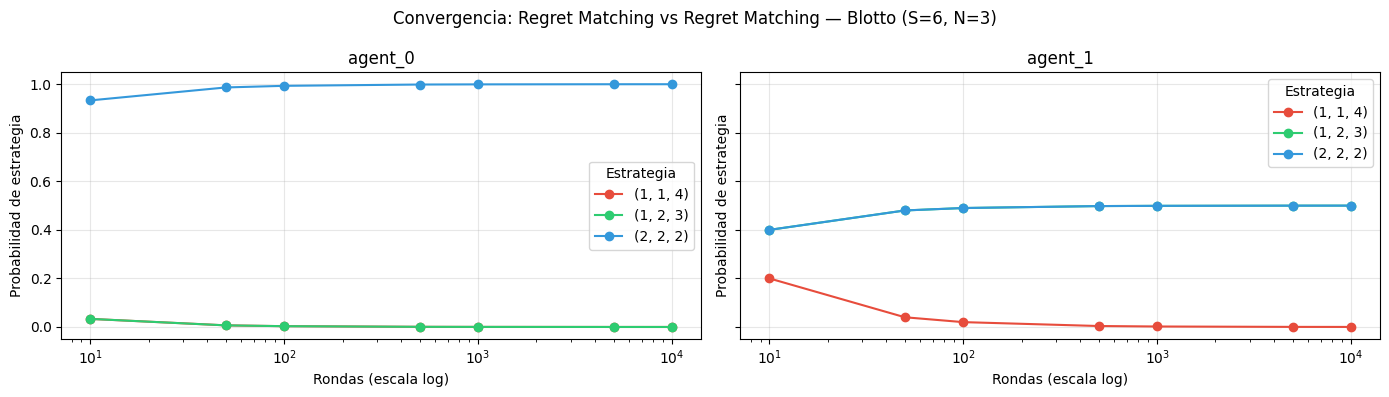

In [37]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Regret Matching — Blotto (S=6, N=3)', g)

### Regret Matching vs Random Agent

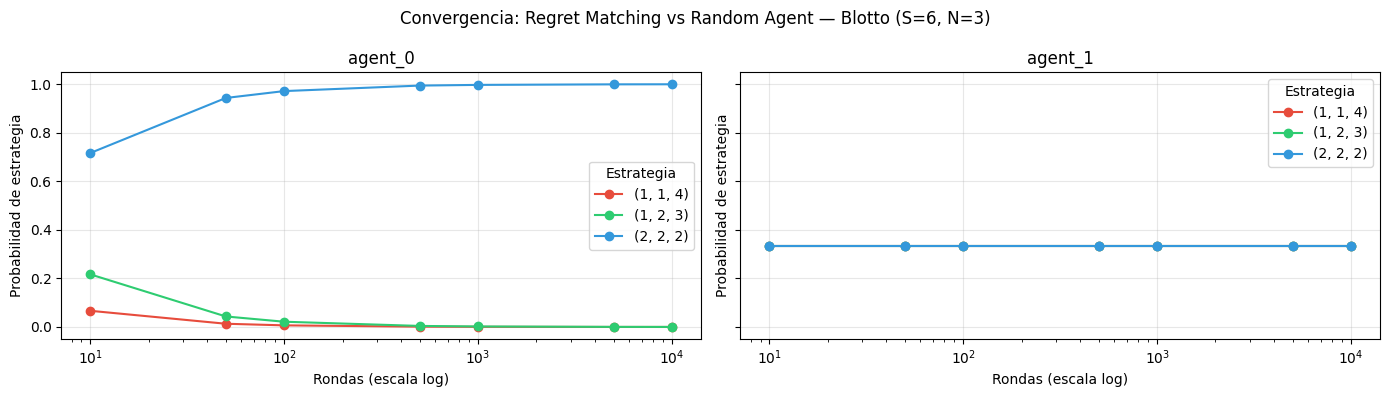

In [38]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Random Agent — Blotto (S=6, N=3)', g)

### Fictitious Play vs Fictitious Play

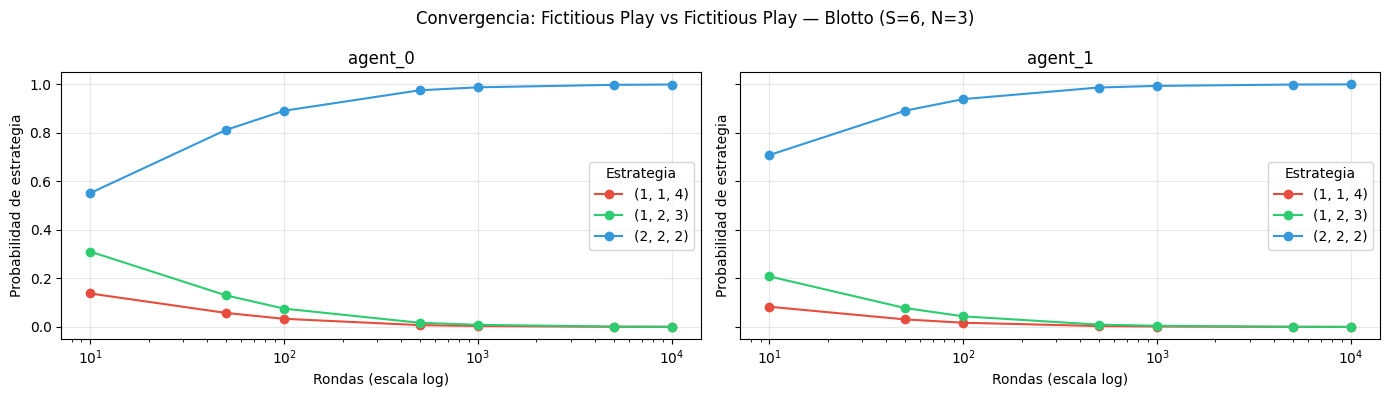

In [39]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Fictitious Play — Blotto (S=6, N=3)', g)

### Fictitious Play vs Random Agent

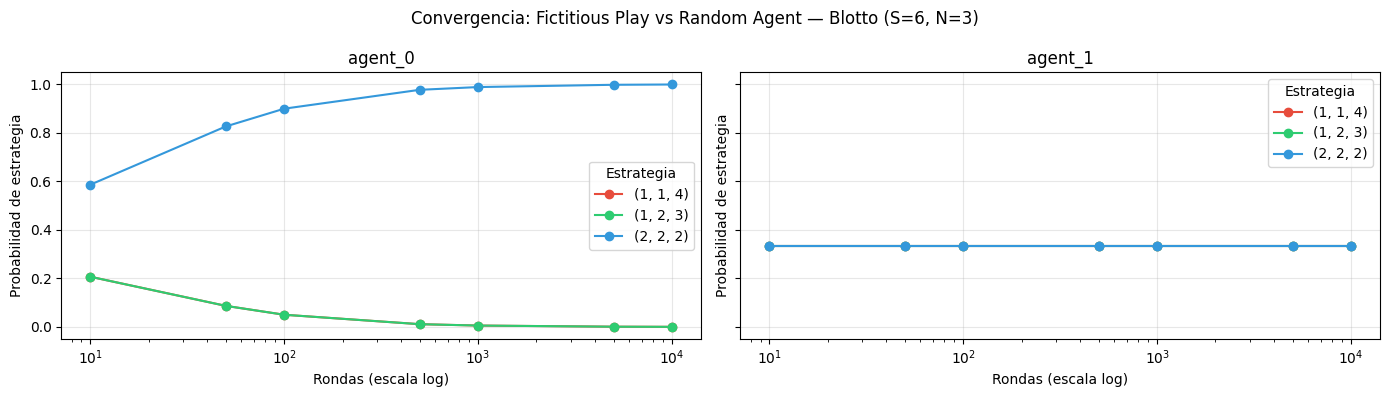

In [40]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Random Agent — Blotto (S=6, N=3)', g)

### IQL vs Random Agent

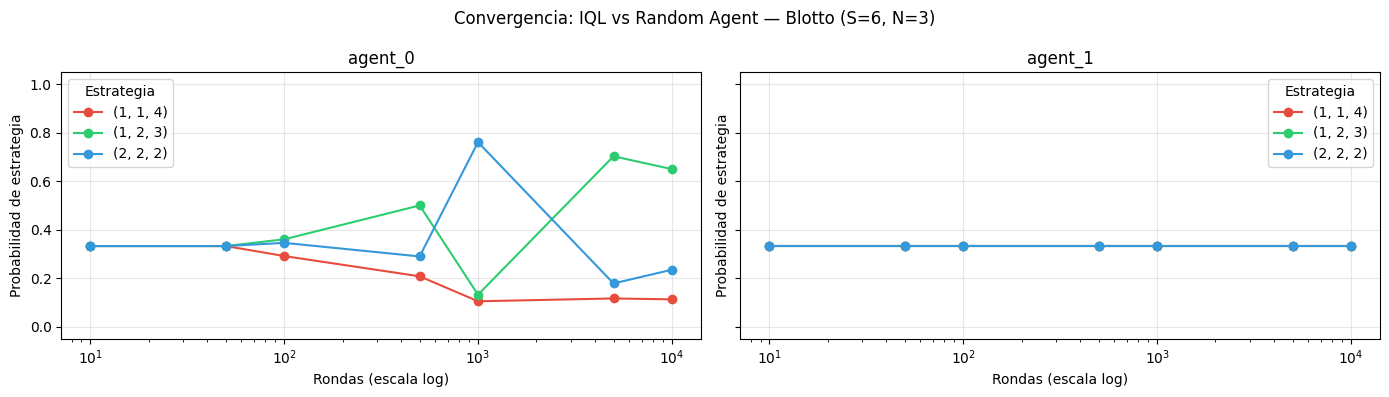

In [41]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs Random Agent — Blotto (S=6, N=3)', g)

### IQL vs IQL

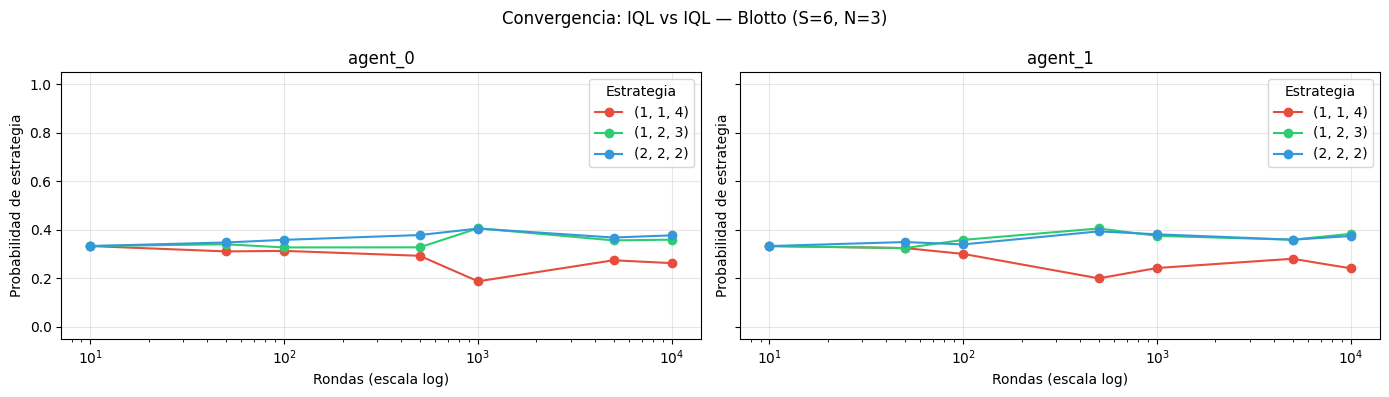

In [42]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs IQL — Blotto (S=6, N=3)', g)

### IQL vs Joint Action Learning AM

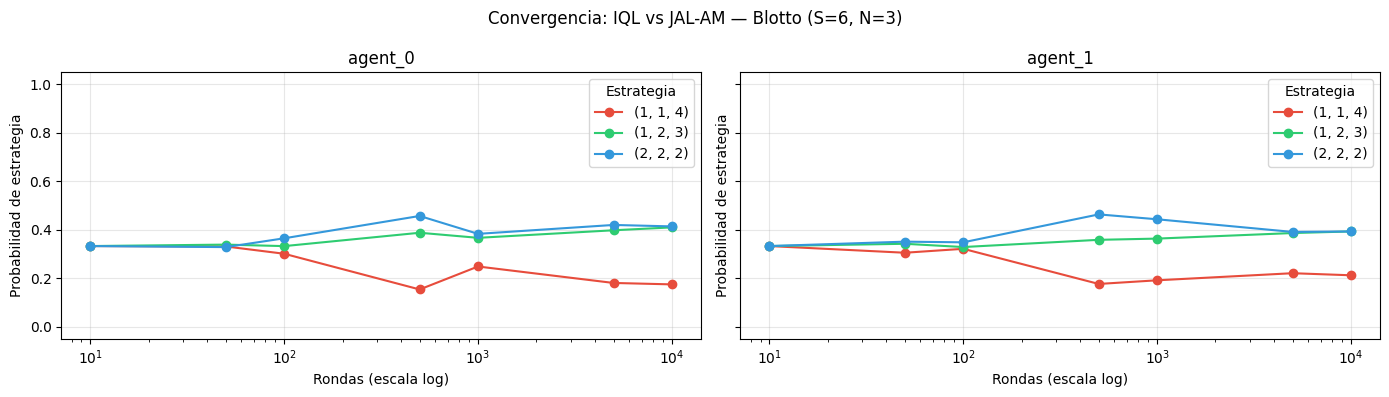

In [43]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs JAL-AM — Blotto (S=6, N=3)', g)

### Joint Action Learning AM vs Joint Action Learning AM

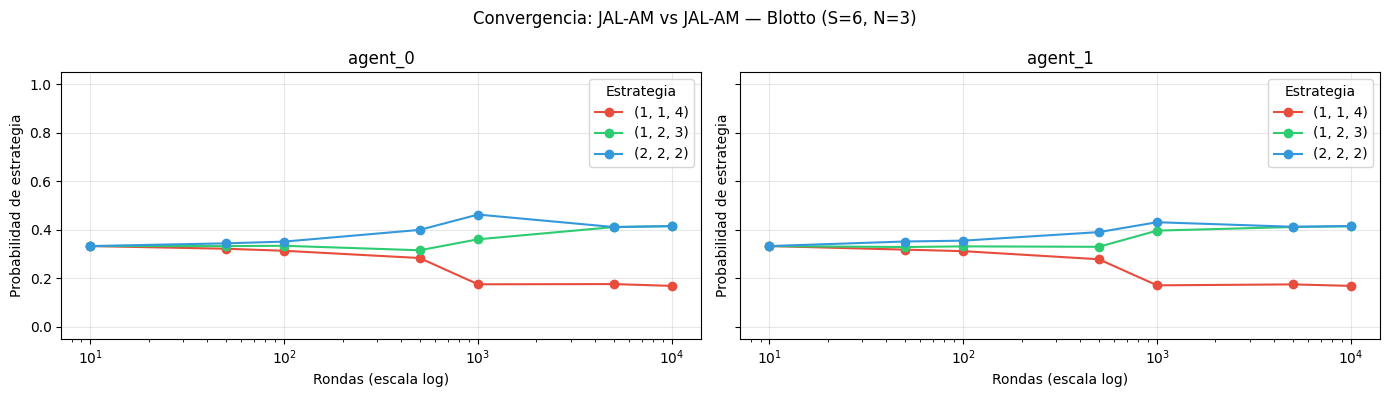

In [44]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: JAL-AM vs JAL-AM — Blotto (S=6, N=3)', g)

### Conclusiones
- Se encontraron dos equilibrios de Nash en $(2, 2, 2)$ y $(1,2,3)$, todos los agentes salvo el Random, tienen a descartar la estrategia dominada $(1,1,4)$
- Analizando la performance por agente, tenemos que:
    - **Ficticious** y **Regret Matching** son los que aprenden más rapido a encontrar una estrategia debilmente dominante.
    - **Random** mitiga entre las estrategias pero sin aprender
    - **JAL-AM** aprende más lento que  **Ficticious** y **Regret Matching** pero arroja resultados válidos, eligiendo con mayor frecuencia a las estrategias débilmente dominantes.
    - **IQL** fue sumamente inestable contra **Random**, en un caso particular en donde **Random** eligió a una de las estrategias débilmente dominantes. Jugando contra él mismo y contra  **JAL-AM** fue un poco más estable. 
    